In [39]:
import pandas as pd


In [40]:
df = pd.read_parquet("../data/raw/insurance_raw.parquet")

print(df.shape)
df.head()


(1000000, 12)


,age,gender,bmi,children,smoker,region,medical_history,family_medical_history,exercise_frequency,occupation,coverage_level,charges
0,46.0,male,21.45,5.0,yes,southeast,Diabetes,None,Never,Blue collar,Premium,20460.307669
1,25.0,female,25.38,2.0,yes,northwest,Diabetes,High blood pressure,Occasionally,White collar,Premium,20390.899218
2,38.0,male,44.88,2.0,yes,southwest,None,High blood pressure,Occasionally,Blue collar,Premium,20204.476302
3,25.0,male,19.89,0.0,no,northwest,None,Diabetes,Rarely,White collar,Standard,11789.029843
4,49.0,male,38.21,3.0,yes,northwest,Diabetes,High blood pressure,Rarely,White collar,Standard,19268.309838


In [41]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 12 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   age                     960000 non-null   float64
 1   gender                  976000 non-null   object 
 2   bmi                     1000000 non-null  float64
 3   children                968000 non-null   float64
 4   smoker                  1000000 non-null  object 
 5   region                  1000000 non-null  object 
 6   medical_history         749238 non-null   object 
 7   family_medical_history  749596 non-null   object 
 8   exercise_frequency      1000000 non-null  object 
 9   occupation              968000 non-null   object 
 10  coverage_level          1000000 non-null  object 
 11  charges                 1000000 non-null  float64
dtypes: float64(4), object(8)
memory usage: 91.6+ MB


In [42]:
df.isnull().sum()

age                        40000
gender                     24000
bmi                            0
children                   32000
smoker                         0
region                         0
medical_history           250762
family_medical_history    250404
exercise_frequency             0
occupation                 32000
coverage_level                 0
charges                        0
dtype: int64

In [43]:
df.describe()

,age,bmi,children,charges
count,960000.000000,1000000.000000,968000.000000,1000000.000000
mean,41.493661,34.001839,2.499985,16735.117481
std,13.855738,9.231680,1.707749,4415.808211
min,18.000000,18.000000,0.000000,3445.011643
25%,30.000000,26.020000,1.000000,13600.372379
50%,41.000000,34.000000,2.000000,16622.127973
75%,53.000000,41.990000,4.000000,19781.465410
max,65.000000,50.000000,5.000000,32561.560374


In [44]:
TARGET = "charges"   # or premium column name
FEATURES = [col for col in df.columns if col != TARGET]

print("Target:", TARGET)
print("Features:", FEATURES)


Target: charges
Features: ['age', 'gender', 'bmi', 'children', 'smoker', 'region', 'medical_history', 'family_medical_history', 'exercise_frequency', 'occupation', 'coverage_level']


In [45]:
df[FEATURES].info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   age                     960000 non-null   float64
 1   gender                  976000 non-null   object 
 2   bmi                     1000000 non-null  float64
 3   children                968000 non-null   float64
 4   smoker                  1000000 non-null  object 
 5   region                  1000000 non-null  object 
 6   medical_history         749238 non-null   object 
 7   family_medical_history  749596 non-null   object 
 8   exercise_frequency      1000000 non-null  object 
 9   occupation              968000 non-null   object 
 10  coverage_level          1000000 non-null  object 
dtypes: float64(3), object(8)
memory usage: 83.9+ MB


In [46]:

df[FEATURES].isnull().mean().sort_values(ascending=False)

medical_history           0.250762
family_medical_history    0.250404
age                       0.040000
children                  0.032000
occupation                0.032000
gender                    0.024000
bmi                       0.000000
smoker                    0.000000
region                    0.000000
exercise_frequency        0.000000
coverage_level            0.000000
dtype: float64

In [47]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

df[num_cols].describe()


,age,bmi,children,charges
count,960000.000000,1000000.000000,968000.000000,1000000.000000
mean,41.493661,34.001839,2.499985,16735.117481
std,13.855738,9.231680,1.707749,4415.808211
min,18.000000,18.000000,0.000000,3445.011643
25%,30.000000,26.020000,1.000000,13600.372379
50%,41.000000,34.000000,2.000000,16622.127973
75%,53.000000,41.990000,4.000000,19781.465410
max,65.000000,50.000000,5.000000,32561.560374


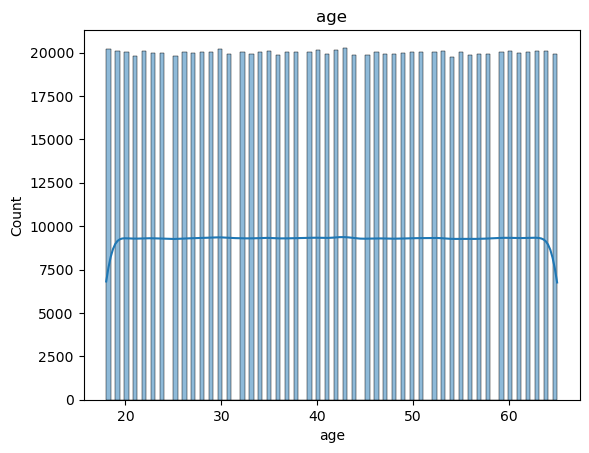

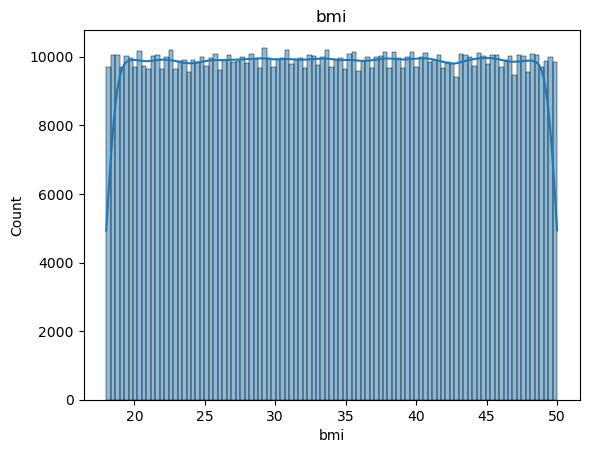

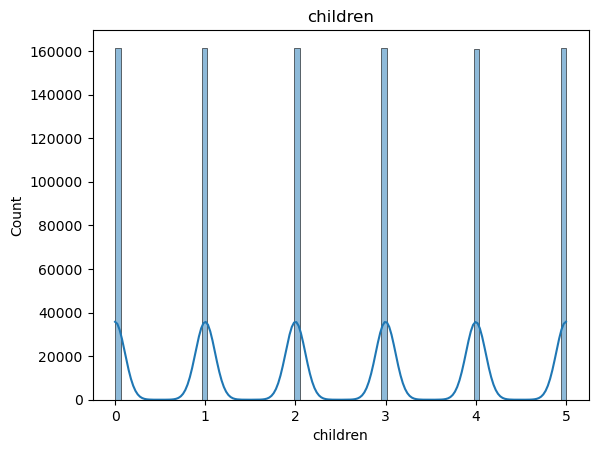

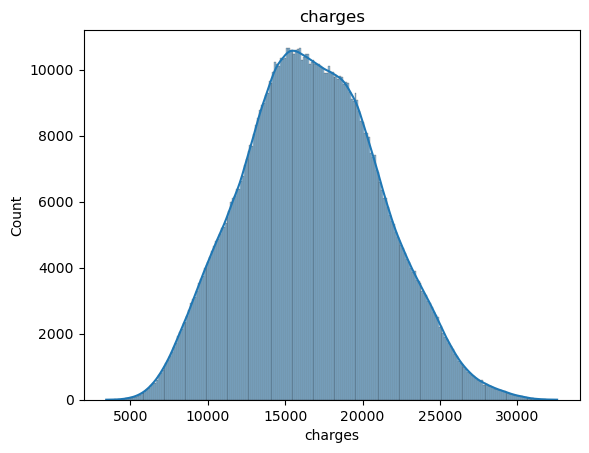

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()


In [49]:
cat_cols = df.select_dtypes(include=["object", "category"]).columns

for col in cat_cols:
    print(df[col].value_counts(normalize=True))


gender
male      0.500155
female    0.499845
Name: proportion, dtype: float64
smoker
yes    0.500129
no     0.499871
Name: proportion, dtype: float64
region
northeast    0.250343
southwest    0.250095
northwest    0.249931
southeast    0.249631
Name: proportion, dtype: float64
medical_history
Heart disease          0.333834
High blood pressure    0.333381
Diabetes               0.332785
Name: proportion, dtype: float64
family_medical_history
Heart disease          0.333560
High blood pressure    0.333278
Diabetes               0.333162
Name: proportion, dtype: float64
exercise_frequency
Rarely          0.250538
Occasionally    0.250362
Frequently      0.249746
Never           0.249354
Name: proportion, dtype: float64
occupation
Unemployed      0.250762
Student         0.250374
Blue collar     0.249697
White collar    0.249166
Name: proportion, dtype: float64
coverage_level
Basic       0.333515
Standard    0.333508
Premium     0.332977
Name: proportion, dtype: float64


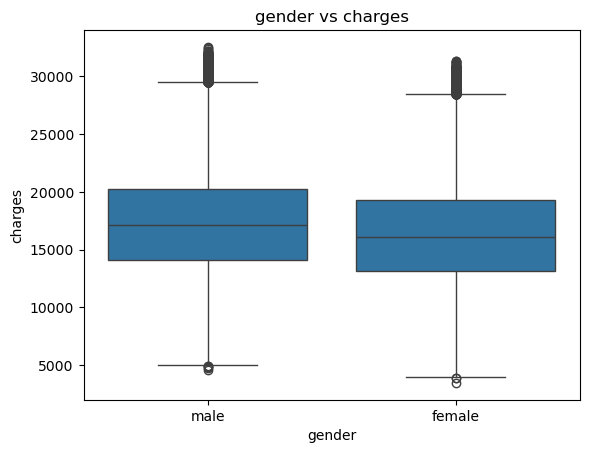

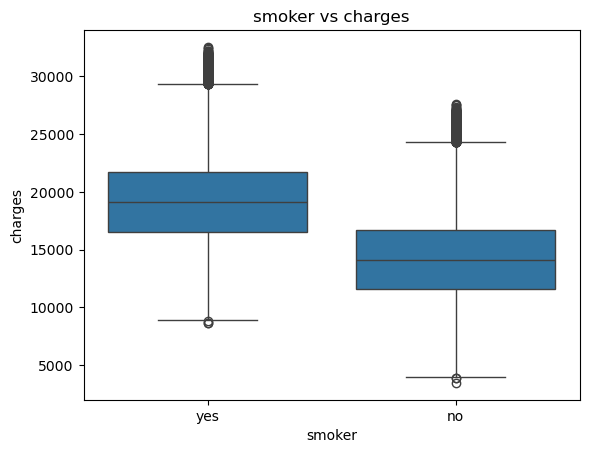

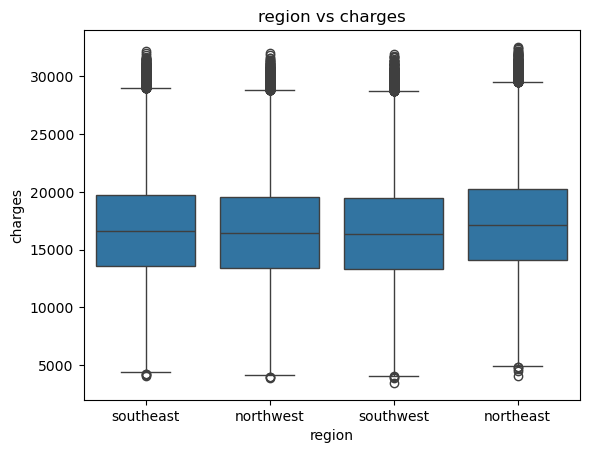

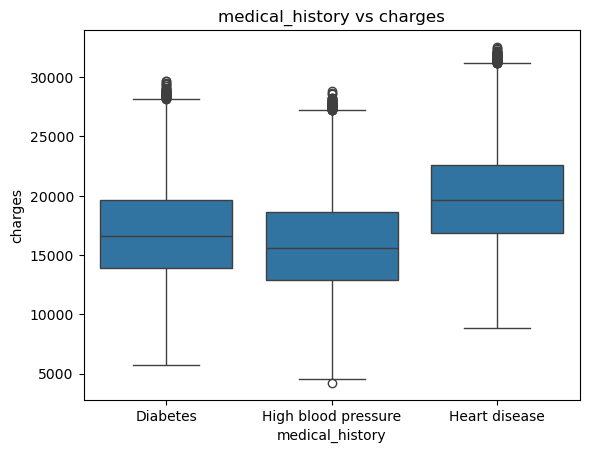

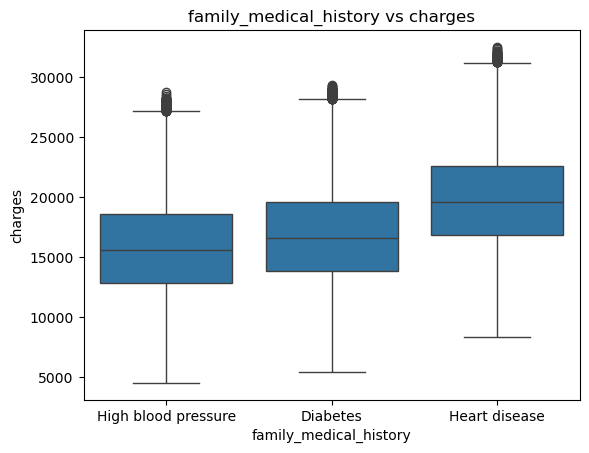

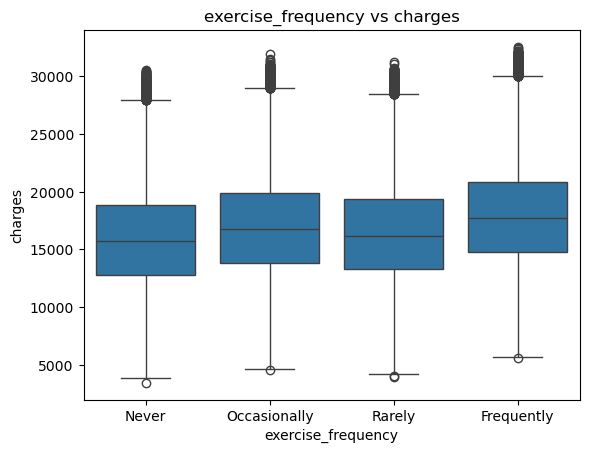

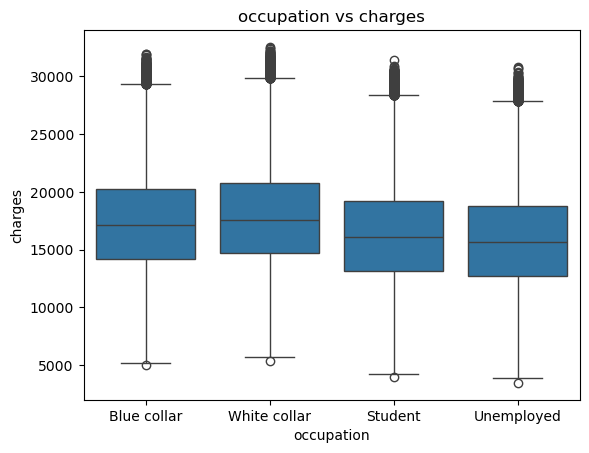

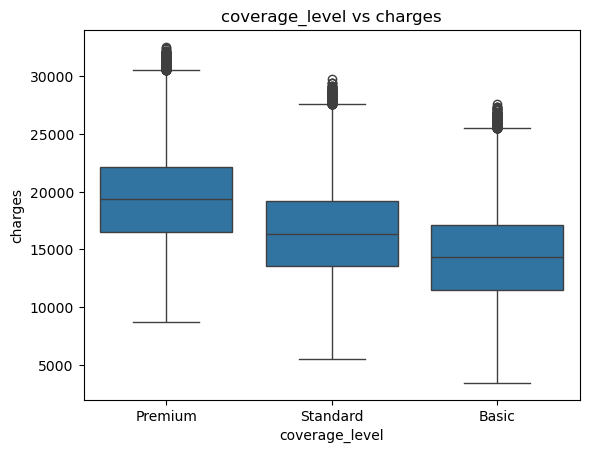

In [50]:
for col in cat_cols:
    sns.boxplot(x=df[col], y=df[TARGET])
    plt.title(f"{col} vs {TARGET}")
    plt.show()


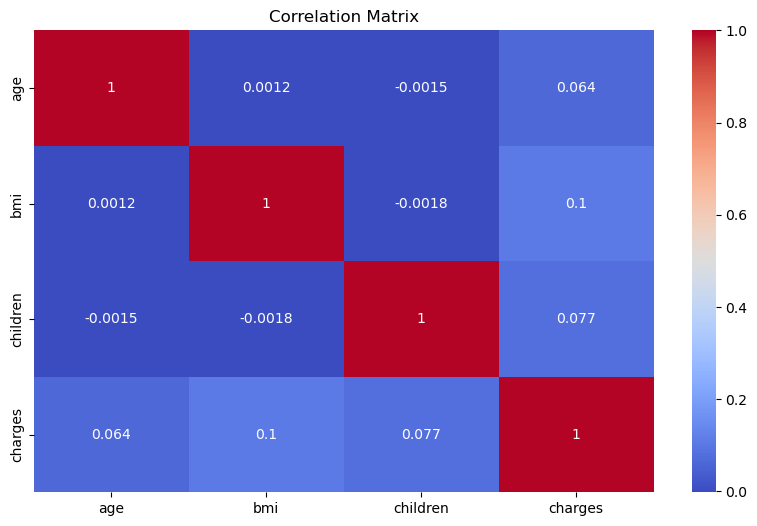

In [51]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


• Smoking status has the strongest impact on insurance premium
• Charges increase exponentially with age for smokers
• BMI shows non-linear relationship with premium
• Region has minimal impact
• Target variable is highly skewed → log transform may help
